# Lab: Análisis de imágenes científicas

**Meta:** ver que una **imagen es un arreglo 2D de NumPy** y analizarla. Abrirás una imagen de microscopía como arreglo, la mostrarás con `plt.imshow`, separarás **célula vs. fondo** con una **umbralización** (`arr > umbral`), medirás el **porcentaje de área** cubierta, y contarás **objetos discretos** (las bandas de un gel) con un **perfil 1D**. Acompaña a la nota de concepto [Análisis de imágenes científicas](l24_concept_scientific_images.qmd).

> **Cómo usar este lab:** ejecuta cada celda con `Shift + Enter`, empezando por las dos celdas de preparación. Algunas celdas **fabrican** una imagen de ejemplo (en la práctica vendría de un microscopio o un escáner) y otras la **analizan**: fíjate en cuál es cuál. Las celdas de gráfica no imprimen texto: abren una figura. Donde diga **Tu turno**, hay un bloque comentado con una parte marcada con `____` que debes **completar** al quitar los `#`. Compara con la respuesta esperada del bloque desplegable.

## Preparación

Para trabajar con imágenes necesitamos **Pillow** (la librería de imágenes de Python, se importa como `PIL`), **NumPy** (la imagen será un arreglo) y **matplotlib** (para mostrarla). Corre estas **dos** celdas primero. La primera las instala (en Colab; si ya están, no hace nada). La segunda las importa.

In [1]:
%pip install -q pillow numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

print("Pillow, NumPy y matplotlib listos para trabajar")

Pillow, NumPy y matplotlib listos para trabajar


~~~text
Pillow, NumPy y matplotlib listos para trabajar
~~~

## Paso 1: una imagen es un arreglo

Primero **fabricamos** una imagen de ejemplo: un campo de microscopía simulado, un fondo oscuro con unas cuantas "células" brillantes. Esta celda no es el tema de hoy (en la práctica la imagen vendría del microscopio); solo crea el archivo con el que trabajaremos.

In [3]:
# Esta celda FABRICA una imagen de ejemplo (no es el tema de hoy).
campo = np.full((80, 100), 40, dtype=np.uint8)   # fondo oscuro: 80 filas x 100 columnas
celulas = [(8, 12, 200), (10, 60, 220), (38, 28, 180), (52, 74, 210),
           (60, 18, 200), (28, 84, 190), (66, 48, 210)]
for (fila, col, brillo) in celulas:
    campo[fila:fila+8, col:col+8] = brillo       # cada celula = un cuadro brillante 8x8
Image.fromarray(campo).save('microscopia.png')
print("imagen 'microscopia.png' creada")

imagen 'microscopia.png' creada


~~~text
imagen 'microscopia.png' creada
~~~

Ahora la abrimos como lo harías con **cualquier** imagen real: `Image.open` la carga y `np.array` la convierte en un arreglo de NumPy. Una imagen en escala de grises es un arreglo **2D** de intensidades enteras de 0 (negro) a 255 (blanco).

In [4]:
img = Image.open('microscopia.png')
arr = np.array(img)

print("formato:", img.format, "| modo:", img.mode, "| tamano:", img.size)
print("type:", type(arr).__name__)
print("shape (alto, ancho):", arr.shape)
print("dtype:", arr.dtype)

formato: PNG | modo: L | tamano: (100, 80)
type: ndarray
shape (alto, ancho): (80, 100)
dtype: uint8


~~~text
formato: PNG | modo: L | tamano: (100, 80)
type: ndarray
shape (alto, ancho): (80, 100)
dtype: uint8
~~~

El `shape` es `(80, 100)`: 80 filas por 100 columnas, justo como la fabricamos. El `dtype` es `uint8` (enteros 0-255). Como es un arreglo, ya sabes operarlo: agregados (`min`/`max`/`mean`) y rebanar una región (todo de la L20).

In [5]:
print("intensidad minima:", arr.min())
print("intensidad maxima:", arr.max())
print("intensidad promedio:", round(float(arr.mean()), 2))
print("una region 4x4 dentro de una celula:")
print(arr[8:12, 12:16])

intensidad minima: 40
intensidad maxima: 220
intensidad promedio: 49.04
una region 4x4 dentro de una celula:
[[200 200 200 200]
 [200 200 200 200]
 [200 200 200 200]
 [200 200 200 200]]


~~~text
intensidad minima: 40
intensidad maxima: 220
intensidad promedio: 49.04
una region 4x4 dentro de una celula:
[[200 200 200 200]
 [200 200 200 200]
 [200 200 200 200]
 [200 200 200 200]]
~~~

El fondo vale 40 y las células llegan a 220; el promedio (49.04) es bajo porque casi todo el campo es fondo. La región que rebanamos cae dentro de una célula: puros 200. Para **ver** el arreglo como imagen usamos `plt.imshow` con el mapa de grises:

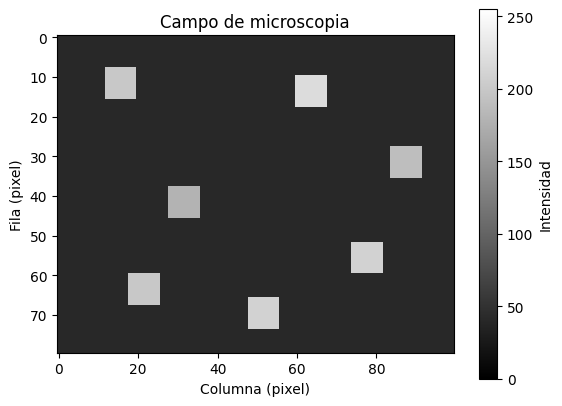

In [6]:
plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.title('Campo de microscopia')
plt.xlabel('Columna (pixel)')
plt.ylabel('Fila (pixel)')
plt.colorbar(label='Intensidad')
plt.show()

*(Al ejecutar se abre la figura: el campo oscuro con siete células brillantes, y una barra de color que mapea intensidad a gris.)*

## Paso 2: formatos -- PNG (sin pérdida) vs. JPEG (con pérdida)

En ciencia importa **en qué formato** se guarda una imagen. **PNG** y **TIFF** son *sin pérdida*: guardan los valores de píxel exactos. **JPEG** es *con pérdida*: comprime alterando los valores. Guardemos el mismo campo en ambos formatos, reabrámoslos y comparemos:

In [7]:
Image.fromarray(campo).save('campo.png')
Image.fromarray(campo).save('campo.jpg', quality=85)

png_otra_vez = np.array(Image.open('campo.png'))
jpg_otra_vez = np.array(Image.open('campo.jpg'))

print("PNG identico al original?:", np.array_equal(campo, png_otra_vez))
print("JPEG identico al original?:", np.array_equal(campo, jpg_otra_vez))
print("diferencia maxima JPEG:", np.abs(campo.astype(int) - jpg_otra_vez.astype(int)).max())

PNG identico al original?: True
JPEG identico al original?: False
diferencia maxima JPEG: 15


~~~text
PNG identico al original?: True
JPEG identico al original?: False
diferencia maxima JPEG: 15
~~~

El PNG devuelve **exactamente** el arreglo original; el JPEG no (algunos píxeles cambian hasta en 15). Por eso una micrografía o un gel se guardan en **PNG/TIFF**: con JPEG estarías midiendo valores que la compresión inventó.

## Paso 3: umbralización y área

La operación central del análisis de imágenes es la **umbralización**: separar la **señal** (las células, brillantes) del **fondo** (oscuro). Es la **máscara booleana de la L20**, ahora sobre una imagen 2D. `arr > 120` da un arreglo de `True`/`False` del mismo tamaño:

In [8]:
umbral = 120
mascara = arr > umbral          # arreglo 2D de booleanos: True = senal, False = fondo

print("mascara dtype:", mascara.dtype)
print("pixeles de senal (mascara.sum()):", mascara.sum())
print("porcentaje de area cubierta:", round(float(mascara.mean()) * 100, 2), "%")

mascara dtype: bool
pixeles de senal (mascara.sum()): 448
porcentaje de area cubierta: 5.6 %


~~~text
mascara dtype: bool
pixeles de senal (mascara.sum()): 448
porcentaje de area cubierta: 5.6 %
~~~

`mascara.sum()` cuenta los `True` (los píxeles de célula): 448. Y `mascara.mean()` es la fracción de píxeles que son señal; por 100 da el **porcentaje de área** cubierta por células: 5.6 %. Esa es una medición científica real ("¿qué fracción del campo está ocupada?"). Veamos la máscara:

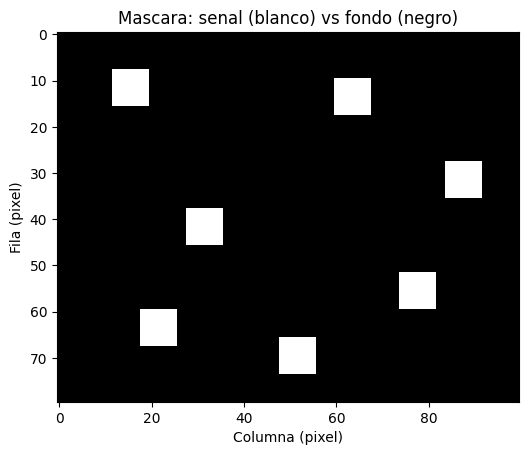

In [9]:
plt.imshow(mascara, cmap='gray')
plt.title('Mascara: senal (blanco) vs fondo (negro)')
plt.xlabel('Columna (pixel)')
plt.ylabel('Fila (pixel)')
plt.show()

*(Al ejecutar se abre la figura: las siete células en blanco sobre un fondo negro. La umbralización dejó solo la señal.)*

## Paso 4: contar objetos -- el perfil 1D de un gel

Medir área no cuenta **objetos separados**. Para eso reducimos la imagen a un **perfil 1D**. En un gel de electroforesis las bandas cruzan el carril; si tomamos **una columna** del arreglo (`g[:, 15]`, rebanar de la L20), obtenemos la intensidad fila por fila: las bandas aparecen como **picos**. Fabriquemos un gel y saquemos su perfil:

In [10]:
# Fabricamos un gel: un carril oscuro con tres bandas brillantes.
gel = np.full((120, 30), 30, dtype=np.uint8)
for fila in (15, 45, 80):
    gel[fila:fila+6, :] = 210
Image.fromarray(gel).save('gel.png')

g = np.array(Image.open('gel.png'))
perfil = g[:, 15]               # una columna vertical por el centro del carril
print("perfil: longitud", len(perfil), "| min", perfil.min(), "| max", perfil.max())

perfil: longitud 120 | min 30 | max 210


~~~text
perfil: longitud 120 | min 30 | max 210
~~~

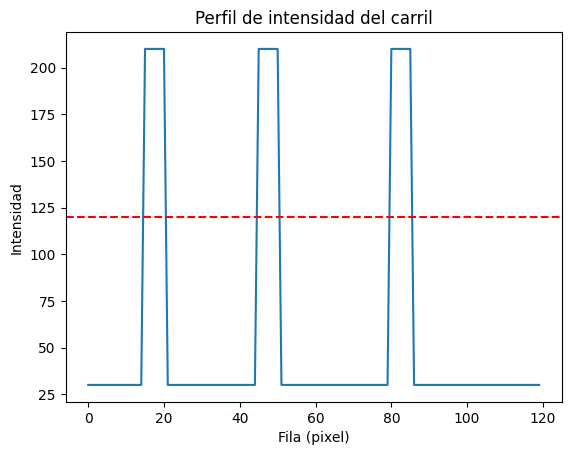

In [11]:
plt.plot(perfil)
plt.axhline(120, color='red', linestyle='--')
plt.title('Perfil de intensidad del carril')
plt.xlabel('Fila (pixel)')
plt.ylabel('Intensidad')
plt.show()

*(Al ejecutar se abre la figura: una curva que sube a 210 en tres tramos -- las tres bandas -- y baja a 30 entre ellas. La línea roja punteada es el umbral 120.)*

Para **contar** las bandas, recorremos el perfil y sumamos 1 cada vez que cruza de **fondo a señal**. Es un recorrido con un `for`, un `if` y un contador (lo de la L08-L11), con un centinela booleano `dentro` que recuerda si ya estamos sobre una banda:

In [12]:
def contar_bandas(perfil, umbral):
    n = 0
    dentro = False
    for valor in perfil:
        if valor > umbral and not dentro:
            n += 1              # empieza una banda nueva
            dentro = True
        elif valor <= umbral:
            dentro = False      # volvimos al fondo
    return n

print("numero de bandas:", contar_bandas(perfil, 120))

numero de bandas: 3


~~~text
numero de bandas: 3
~~~

Tres bandas, sin ninguna librería extra: solo NumPy y los fundamentos del curso aplicados a un arreglo.

## Tu turno (programa completo)

### Ejercicio: contar los picos de un espectro (química)

Un cromatograma o espectro es una curva 1D (absorbancia o señal contra tiempo) con **picos** donde aparece un compuesto. Es el mismo problema que el gel: contar cuántos picos superan un umbral. Tienes el cromatograma `crom` (línea base 5; cuatro picos de alto 70 a 150). Usa `contar_bandas` para contar los picos. Completa el umbral que falta.

In [13]:
# Un cromatograma simulado: linea base baja con cuatro picos.
crom = np.full(60, 5, dtype=np.uint8)
for centro, alto in [(8, 90), (22, 150), (38, 70), (50, 120)]:
    crom[centro-2:centro+3] = alto

# TODO: quita los # y completa el ____ con un umbral que separe los picos del fondo.
# La linea base vale 5 y los picos valen 70 o mas: un umbral de 40 los separa bien.
# n_picos = contar_bandas(crom, ____)
# print("numero de picos:", n_picos)

<details><summary>Respuesta esperada</summary>

El umbral 40 queda por encima de la línea base (5) y por debajo del pico más bajo (70), así que separa los cuatro picos del fondo:

~~~python
n_picos = contar_bandas(crom, 40)
print("numero de picos:", n_picos)
~~~

Al ejecutarlo imprime `numero de picos: 4`. Es la misma técnica del gel: la función recorre la curva y suma 1 cada vez que cruza de fondo a pico. Si subieras el umbral por encima de 70, el pico más bajo (alto 70) dejaría de contar y quedarían 3; por encima de 90 perderías también el de alto 90 y quedarían 2. El umbral es una **decisión** que cambia el resultado.
</details>

## Resumen

- Una imagen en escala de grises es un **arreglo 2D de NumPy** de intensidades 0-255; se abre con `Image.open` + `np.array` y se muestra con `plt.imshow(arr, cmap='gray')`.
- **Formatos:** PNG/TIFF son **sin pérdida** (valores exactos); JPEG es **con pérdida** (los altera). La ciencia usa PNG/TIFF.
- **Umbralización:** `mascara = arr > umbral` separa señal de fondo (la máscara booleana de la L20, en 2D).
- **Área:** `mascara.sum()` cuenta los píxeles de señal; `mascara.mean()*100` da el porcentaje de área cubierta.
- **Contar objetos:** reduce la imagen a un **perfil 1D** (una columna `arr[:, c]`) y cuenta los cruces de fondo a señal con una función de estado. Sirve para bandas de gel y picos de espectro.
- **Sigue en la L25:** otro tipo de dato científico, las **secuencias de ADN**, con la librería **Biopython**.